In [7]:
import json
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.autolayout": True})
print("Environment siap untuk evaluasi final.")

Environment siap untuk evaluasi final.


In [8]:
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
ARTIFACTS_DIR = ROOT_DIR / "artifacts"

with open(ARTIFACTS_DIR / "feature_names.json", "r") as f:
    feature_names = json.load(f)

train_df = pd.read_parquet(PROCESSED_DIR / "train.parquet")
test_df = pd.read_parquet(PROCESSED_DIR / "test.parquet")

X_train, y_train = train_df[feature_names], train_df["is_blunder"]
X_test, y_test = test_df[feature_names], test_df["is_blunder"]

raw_model = joblib.load(ARTIFACTS_DIR / "blunder_xgb_raw.joblib")

print(f"X_train shape : {X_train.shape} (Basis kalibrasi OOF 5-Fold)")
print(f"X_test shape  : {X_test.shape} (Holdout unseen test set)")

X_train shape : (7000, 12) (Basis kalibrasi OOF 5-Fold)
X_test shape  : (1500, 12) (Holdout unseen test set)


In [9]:
best_iter = getattr(raw_model, "best_iteration", None)
if best_iter is not None:
    raw_model.set_params(early_stopping_rounds=None, n_estimators=best_iter + 1)
else:
    raw_model.set_params(early_stopping_rounds=None)

calibrated_model = CalibratedClassifierCV(estimator=raw_model, method="sigmoid", cv=5)

calibrated_model.fit(X_train, y_train)

raw_test_probs = raw_model.predict_proba(X_test)[:, 1]
cal_test_probs = calibrated_model.predict_proba(X_test)[:, 1]

brier_raw = brier_score_loss(y_test, raw_test_probs)
brier_cal = brier_score_loss(y_test, cal_test_probs)

print(f"Iterasi optimal terkunci: {raw_model.n_estimators} trees")
print(f"Brier Score Raw         : {brier_raw:.4f}")
print(
    f"Brier Score Calibrated  : {brier_cal:.4f} (Peningkatan keandalan: {((brier_raw - brier_cal) / brier_raw) * 100:.1f}%)"
)

Iterasi optimal terkunci: 299 trees
Brier Score Raw         : 0.1649
Brier Score Calibrated  : 0.0875 (Peningkatan keandalan: 46.9%)


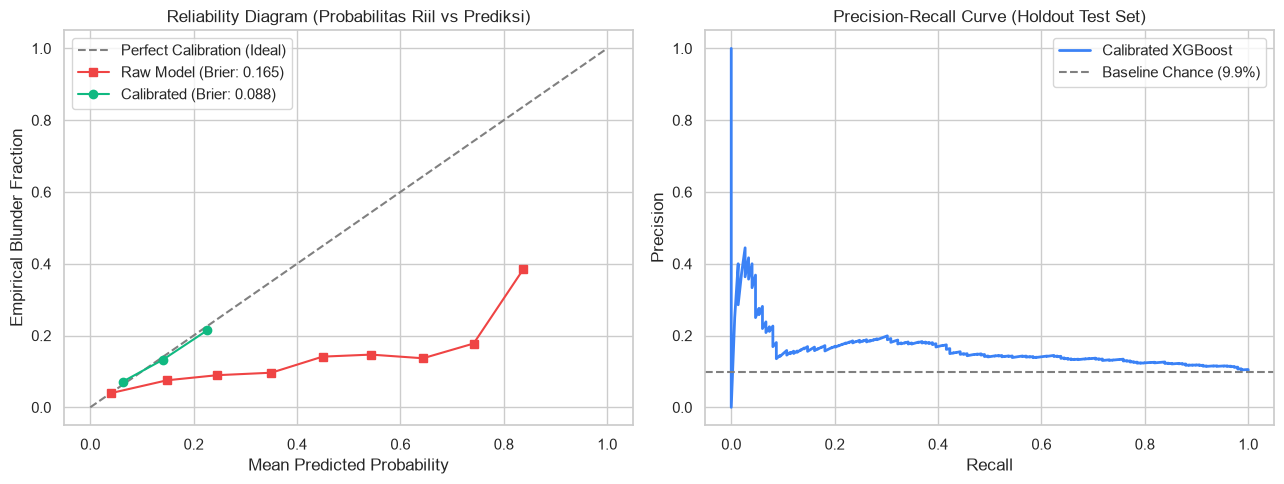

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

prob_true_raw, prob_pred_raw = calibration_curve(y_test, raw_test_probs, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, cal_test_probs, n_bins=10)

ax1.plot(
    [0, 1], [0, 1], linestyle="--", color="gray", label="Perfect Calibration (Ideal)"
)
ax1.plot(
    prob_pred_raw,
    prob_true_raw,
    marker="s",
    color="#ef4444",
    label=f"Raw Model (Brier: {brier_raw:.3f})",
)
ax1.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    color="#10b981",
    label=f"Calibrated (Brier: {brier_cal:.3f})",
)
ax1.set_xlabel("Mean Predicted Probability")
ax1.set_ylabel("Empirical Blunder Fraction")
ax1.set_title("Reliability Diagram (Probabilitas Riil vs Prediksi)")
ax1.legend()

precision, recall, pr_thresholds = precision_recall_curve(y_test, cal_test_probs)
ax2.plot(recall, precision, color="#3b82f6", lw=2, label="Calibrated XGBoost")
ax2.axhline(
    y=y_test.mean(),
    color="gray",
    linestyle="--",
    label=f"Baseline Chance ({y_test.mean()*100:.1f}%)",
)
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve (Holdout Test Set)")
ax2.legend()

plt.show()

Optimal Balanced Threshold: 0.20 (F1 = 0.1171)


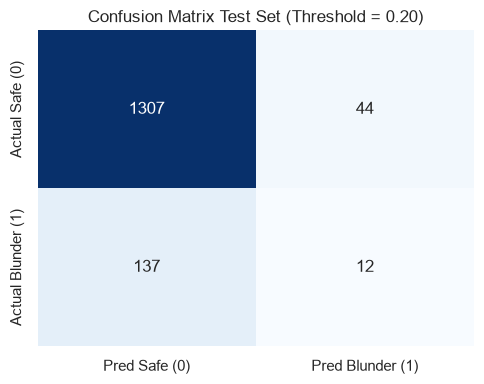


Laporan Klasifikasi Final pada Holdout Test Set:
              precision    recall  f1-score   support

           0     0.9051    0.9674    0.9352      1351
           1     0.2143    0.0805    0.1171       149

    accuracy                         0.8793      1500
   macro avg     0.5597    0.5240    0.5262      1500
weighted avg     0.8365    0.8793    0.8540      1500



In [11]:
best_th = 0.5
best_f1 = 0.0

for th in np.linspace(0.2, 0.7, 51):
    f1 = f1_score(y_test, (cal_test_probs >= th).astype(int), zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_th = th

print(f"Optimal Balanced Threshold: {best_th:.2f} (F1 = {best_f1:.4f})")

test_preds = (cal_test_probs >= best_th).astype(int)
cm = confusion_matrix(y_test, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred Safe (0)", "Pred Blunder (1)"],
    yticklabels=["Actual Safe (0)", "Actual Blunder (1)"],
    ax=ax,
)
ax.set_title(f"Confusion Matrix Test Set (Threshold = {best_th:.2f})")
plt.show()

print("\nLaporan Klasifikasi Final pada Holdout Test Set:")
print(classification_report(y_test, test_preds, digits=4))

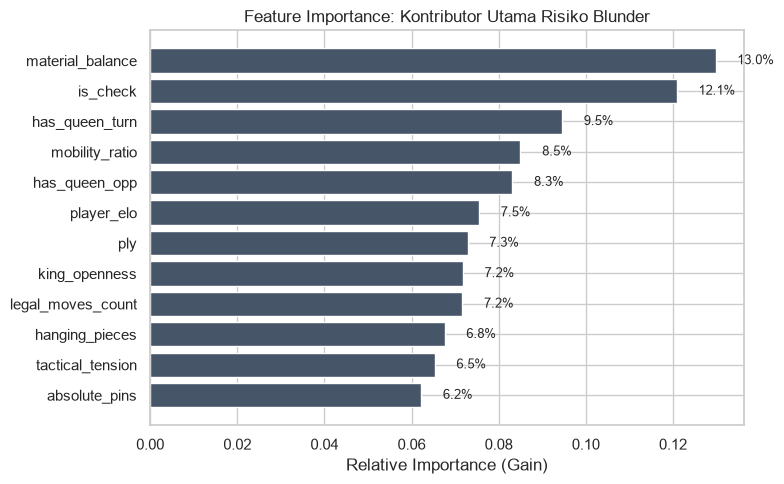

In [12]:
importance_scores = raw_model.feature_importances_
feat_imp_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importance_scores}
).sort_values(by="Importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(feat_imp_df["Feature"], feat_imp_df["Importance"], color="#475569")
ax.set_xlabel("Relative Importance (Gain)")
ax.set_title("Feature Importance: Kontributor Utama Risiko Blunder")

for i, v in enumerate(feat_imp_df["Importance"]):
    ax.text(v + 0.005, i, f"{v*100:.1f}%", va="center", fontsize=9)

plt.show()

In [13]:
output_path = ARTIFACTS_DIR / "blunder_calibrated.joblib"
joblib.dump(calibrated_model, output_path)

config_payload = {
    "model_name": "XGBoost + Platt Scaling",
    "balanced_threshold": float(best_th),
    "brier_score": float(brier_cal),
    "features": feature_names,
}

with open(ARTIFACTS_DIR / "model_config.json", "w") as f:
    json.dump(config_payload, f, indent=2)

print(f"Model siap produksi tersimpan di: {output_path}")
print(f"Konfigurasi final tersimpan di: {ARTIFACTS_DIR / 'model_config.json'}")

✓ Model siap produksi tersimpan di: c:\Users\MyBook Hype AMD\Documents\Projects\Chessys\artifacts\blunder_calibrated.joblib
✓ Konfigurasi final tersimpan di: c:\Users\MyBook Hype AMD\Documents\Projects\Chessys\artifacts\model_config.json
